In [2]:
# pip install mysql-connector-python pandas

In [3]:
# import pandas as pd
# import mysql.connector
# import os

# # List of CSV files and their corresponding table names
# csv_files = [
#     ('customers.csv', 'customers'),
#     ('orders.csv', 'orders'),
#     ('sellers.csv', 'sellers'),
#     ('products.csv', 'products'),
#     ('geolocation.csv', 'geolocation'),
#     ('payments.csv', 'payments') ,
#     ('order_items.csv','order_items') # Added payments.csv for specific handling
# ]

# # Connect to the MySQL database
# conn = mysql.connector.connect(
#     host='localhost',
#     user='root',
#     password='Sairaj@123',
#     database='ecommerce'
# )
# cursor = conn.cursor()

# # Folder containing the CSV files
# folder_path = r'C:\Users\Pranavraj\Downloads\Pranavraj\Ecommerce'

# def get_sql_type(dtype):
#     if pd.api.types.is_integer_dtype(dtype):
#         return 'INT'
#     elif pd.api.types.is_float_dtype(dtype):
#         return 'FLOAT'
#     elif pd.api.types.is_bool_dtype(dtype):
#         return 'BOOLEAN'
#     elif pd.api.types.is_datetime64_any_dtype(dtype):
#         return 'DATETIME'
#     else:
#         return 'TEXT'

# for csv_file, table_name in csv_files:
#     file_path = os.path.join(folder_path, csv_file)
    
#     # Read the CSV file into a pandas DataFrame
#     df = pd.read_csv(file_path)
    
#     # Replace NaN with None to handle SQL NULL
#     df = df.where(pd.notnull(df), None)
    
#     # Debugging: Check for NaN values
#     print(f"Processing {csv_file}")
#     print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

#     # Clean column names
#     df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

#     # Generate the CREATE TABLE statement with appropriate data types
#     columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
#     create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
#     cursor.execute(create_table_query)

#     # Insert DataFrame data into the MySQL table
#     for _, row in df.iterrows():
#         # Convert row to tuple and handle NaN/None explicitly
#         values = tuple(None if pd.isna(x) else x for x in row)
#         sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
#         cursor.execute(sql, values)

#     # Commit the transaction for the current CSV file
#     conn.commit()

# # Close the connection
# conn.close()

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import mysql.connector

db = mysql.connector.connect(host = "localhost",
                             username = "root",
                             password = "Sairaj@123",
                             database = "ecommerce")

cur = db.cursor()


1. List all unique cities where customers are located.

In [5]:
query = """select distinct(customer_city) from customers"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)
df

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
...,...
4114,siriji
4115,natividade da serra
4116,monte bonito
4117,sao rafael


2. Count the number of orders placed in 2017.

In [6]:
query1 ="""select count(order_id) from orders where year(order_purchase_timestamp) = 2017"""

cur.execute(query1)
data = cur.fetchall()
data[0][0]

90202

3. Find the total sales per category.

In [7]:
query = """select products.product_category  category, sum(payments.payment_value) sales
from products join order_items on products.product_id = order_items.product_id
join payments on payments.order_id = order_items.order_id
group by category"""

cur.execute(query)
data = cur.fetchall()


df = pd.DataFrame(data)
df

,0,1
0,perfumery,1.013477e+06
1,Furniture Decoration,2.860353e+06
2,telephony,9.737641e+05
3,bed table bath,3.425107e+06
4,automotive,1.704589e+06
...,...,...
69,cds music dvds,2.398860e+03
70,La Cuisine,5.827060e+03
71,Fashion Children's Clothing,1.571340e+03
72,PC Gamer,4.348860e+03


4. Calculate the percentage of orders that were paid in installments.

In [8]:
query ="""select (sum(case when payment_installments >= 1 then 1
else 0 end))/count(*)*100 from payments"""

cur.execute(query)
data = cur.fetchall()
"the percentage of orders that were paid in installments ",data[0][0]

('the percentage of orders that were paid in installments ',
 Decimal('99.9981'))

5. Count the number of customers from each state.

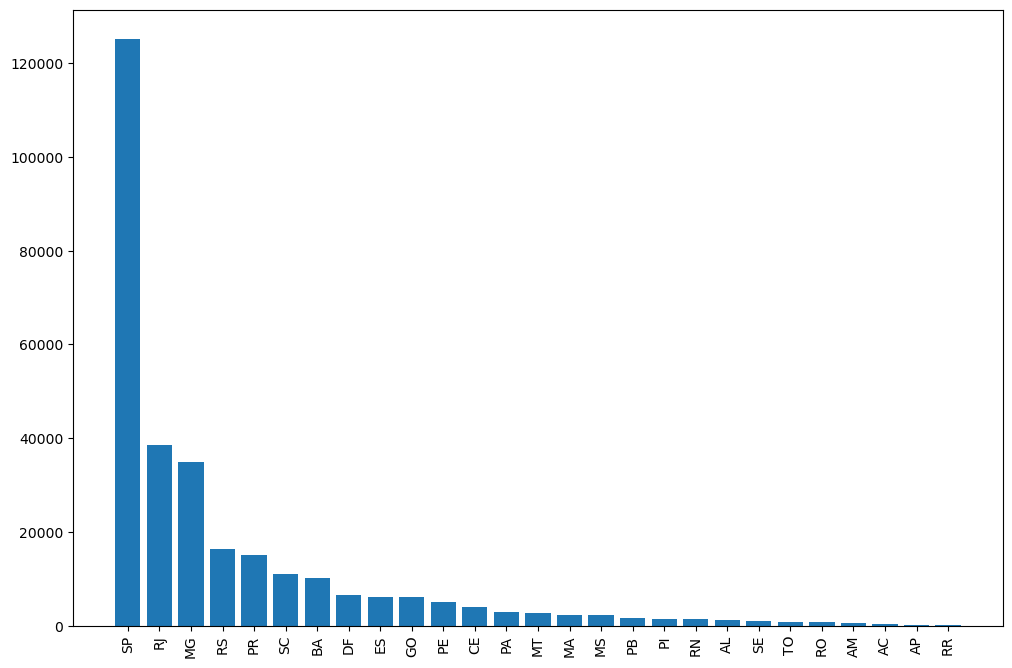

In [9]:
query = """select customer_state,count(customer_id)
from customers
group by customer_state"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["state" ,"count"])
df = df.sort_values(by="count",ascending=False)

plt.figure(figsize=(12,8))
plt.bar(df["state"], df["count"])
plt.xticks(rotation = 90)
plt.show()

1. Calculate the number of orders per month in 2018.

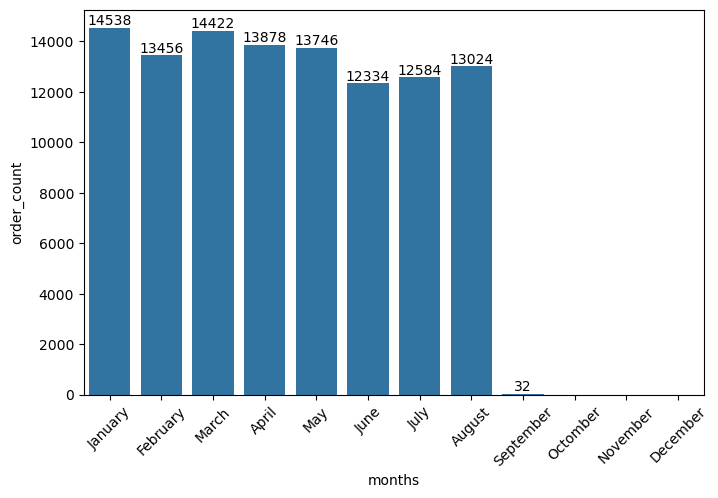

In [10]:
query ="""select monthname(order_purchase_timestamp) months , count(order_id) order_count
from orders
where year(order_purchase_timestamp) = 2018 
group by months"""

cur.execute(query)
data= cur.fetchall()
df = pd.DataFrame(data , columns =["months","order_count"])
o = ["January","February","March","April","May","June","July","August","September","Octomber","November","December"]

plt.figure(figsize=(8,5))
ax = sns.barplot(x =df["months"], y =df["order_count"] , data= df,order = o)
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.show()


2. Find the average number of products per order, grouped by customer city.

In [11]:
query = """with count_per_order as
(select orders.order_id , orders.customer_id,count(order_items.order_id)as oc
from orders join order_items on orders.order_id = order_items.order_id
group by orders.order_id , orders.customer_id)

select customers.customer_city , round(avg(count_per_order.oc),2) average_order
from customers join count_per_order on customers.customer_id = count_per_order.customer_id
group by customers.customer_city 
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data , columns=["customer city" , "Average product per orders"])
df.head(10)

,customer city,Average product per orders
0,treze tilias,2.55
1,indaial,2.23
2,sao jose dos campos,2.28
3,sao paulo,2.31
4,porto alegre,2.35
5,santos,2.32
6,sao francisco do sul,2.47
7,sao vicente,2.18
8,joinville,2.21
9,sao vendelino,2.00


3. Calculate the percentage of total revenue contributed by each product category.


In [12]:
query ="""select upper(ecommerce.products.product_category) as  category, round(sum(ecommerce.payments.payment_value))/(select sum(payment_value) from ecommerce.payments)* 100 as sales_percentage
from ecommerce.products join ecommerce.order_items on ecommerce.products.product_id = ecommerce.order_items.product_id
join ecommerce.payments on ecommerce.payments.order_id = ecommerce. order_items.order_id
group by category order by sales_percentage desc;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data , columns=["category" , "percentage distribution"])
df.head()

,category,percentage distribution
0,BED TABLE BATH,21.395055
1,HEALTH BEAUTY,20.705681
2,COMPUTER ACCESSORIES,19.805649
3,FURNITURE DECORATION,17.867299
4,WATCHES PRESENT,17.855305


4. Identify the correlation between product price and the number of times a product has been purchased.


In [13]:
import numpy as np

query = """select products.product_category, count(order_items.product_id) as count , round(avg(order_items.price) ,2) as Average
from ecommerce.products join ecommerce.order_items
on products.product_id = order_items.product_id
group by products.product_category;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data , columns=["Category","Order_count","Price"])


arr1 = df["Order_count"]
arr2 = df["Price"]

a =np.corrcoef([arr1,arr2])
print("the correlation between price and number of times a product has been purchased is", a[0][1])

the correlation between price and number of times a product has been purchased is -0.10631514167157562


5. Calculate the total revenue generated by each seller, and rank them by revenue.

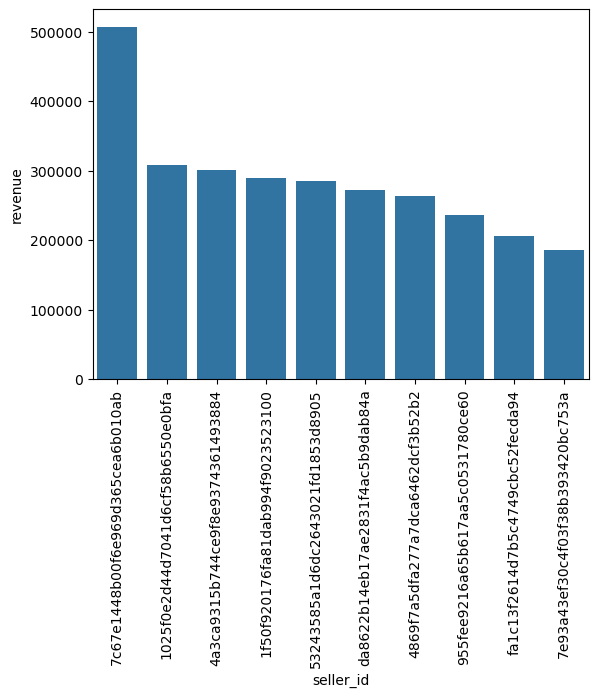

In [14]:
query = """select * ,dense_rank() over(order by revenue desc) as rn from 
(select order_items.seller_id , sum(payments.payment_value) as revenue
from order_items join payments 
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a"""

cur.execute(query)
data = cur.fetchall()


df = pd.DataFrame(data ,columns=["seller_id","revenue","rank"])
df = df.head(10)
sns.barplot(x = "seller_id" , y = "revenue" , data = df)
plt.xticks(rotation = 90)
plt.show()

1. Calculate the moving average of order values for each customer over their order history.

In [15]:
query ="""select customer_id , order_purchase_timestamp,
avg(payment) over (partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from (select orders.customer_id , orders.order_purchase_timestamp,
	payments.payment_value as payment
	from Payments join orders
	on Payments.order_id = orders.order_id) as a;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df


,0,1,2
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
2,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
3,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
4,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.419998
...,...,...,...
207767,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.130005
207768,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.500000
207769,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.500000
207770,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.370001


2. Calculate the cumulative sales per month for each year.

In [16]:
query = """select years, months ,payment,sum(payment) 
over (order by years ,months ) as cumulative_sales
from (select year(orders.order_purchase_timestamp) as years,
			month(orders.order_purchase_timestamp) as months,
			round(sum(payments.payment_value),2) as payment 
	from ecommerce.orders join ecommerce.payments
	on orders.order_id = payments.order_id
	group by years , months
	order by years , months) as a;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df



,0,1,2,3
0,2016,9,504.48,504.48
1,2016,10,118180.96,118685.44
2,2016,12,39.24,118724.68
3,2017,1,276976.08,395700.76
4,2017,2,583816.02,979516.78
5,2017,3,899727.20,1879243.98
6,2017,4,835576.06,2714820.04
7,2017,5,1185837.64,3900657.68
8,2017,6,1022552.76,4923210.44
9,2017,7,1184765.84,6107976.28


3. Calculate the year-over-year growth rate of total sales.

In [17]:
query ="""
select years ,((payment-lag(payment ,1) over(order by years))/lag(payment ,1) over(order by years))*100 
from 
(select year(orders.order_purchase_timestamp) as years,
			round(sum(payments.payment_value),2) as payment 
	from ecommerce.orders join ecommerce.payments
	on orders.order_id = payments.order_id
	group by years 
	order by years) as a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data , columns=["years","yoy % growth"])
df


,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


4. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [18]:
query ="""with a as (select customers.customer_id, 
min(orders.order_purchase_timestamp) as first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id , 
count(distinct orders.order_purchase_timestamp) as next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < date_add(first_order,interval 6 month)
group by customer_id)

select  100 * count(distinct a.customer_id)/ count(distinct b.customer_id)
from a left join b
on a.customer_id = b .customer_id;"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data)
df


,0
0,None


5. Identify the top 3 customers who spent the most money in each year.

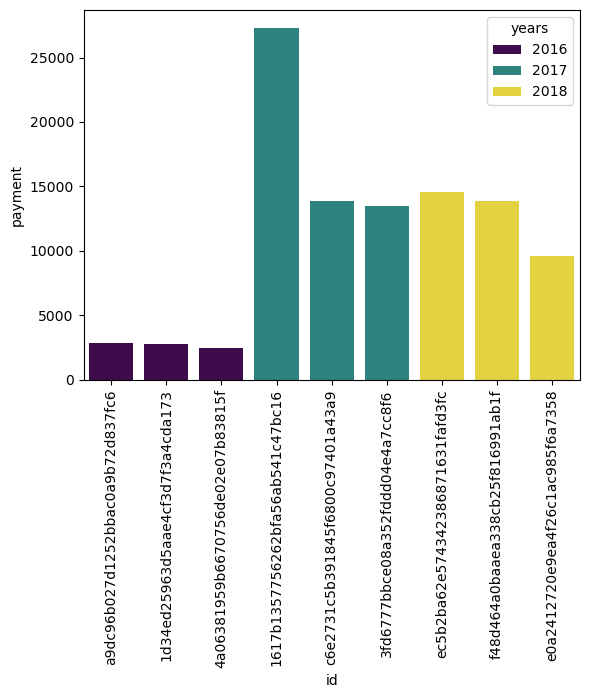

In [25]:
query="""select years , customer_id ,payment,d_rank
from
(select year(orders.order_purchase_timestamp) as years,
orders.customer_id,
sum(payments.payment_value) as payment, 
dense_rank() over (partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from ecommerce.orders join ecommerce.payments
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a
where d_rank <= 3;"""



cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data ,columns=["years", "id","payment","rank"])
df

sns.barplot(x ="id", y ="payment",data =df,hue="years",palette="viridis")
plt.xticks(rotation=90)
plt.show()